# Water-transfer validation energy uncertainty

Analyze a best-model checkpoint trained with `save_cho_factor=True`. Set `RUN_DIR` below to the training run to analyze; the loaded model remains a fixed snapshot throughout the analysis.

Dataset lookup follows the [training tutorial](training.ipynb): `DATASET_REGISTRY.get_path` retrieves the `water-transfer` validation split from `CacheDir.get()`, downloading it if needed. Load the saved model with `FrankenPotential.load`, as in the [model-loading documentation](../docs/topics/interface_torchsim.md).

`predict(["energy"], ..., compute_gp_uncertainty=True, energy_uncertainty_per_atom=True)` returns both the pooled energy score and a score for each atomic energy contribution before pooling. These are **posterior/prior standard-deviation ratios** $r=\|V^{-T}\phi\|/\|\phi\|$ in **[0, 1]**, using the saved prior-normalized factor $V=U/\sqrt{\lambda}$. Near zero means training strongly constrains the feature direction; near one means little uncertainty reduction from the prior. These dimensionless ratios are not probabilities of accurate predictions. Use a checkpoint produced by the current trainer, which saves this normalized factor.

Backbone inference uses float32 for speed; the Cholesky solve retains the checkpoint factor's precision. Only energy is requested, so no force Jacobians or e3nn/JIT patches are needed.

Every validation frame is processed in its original file order, with zero-based frame indices. The trajectory plot shows **median per-atom energy uncertainty** with your median ± IQR band; pooled and maximum per-atom scores are also saved in the CSV. The pooled score is evaluated on the pooled feature vector, not obtained by averaging the atomic scores.

Reference total energies are read from the ASE dataset. Signed energy error is prediction minus reference; the error–uncertainty scatter compares **absolute energy error in meV/atom** against **median per-atom uncertainty**. The score is dimensionless, so a numerical equality line would not represent energy parity.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import iqr
import pandas as pd
import torch
from tqdm.auto import tqdm

from franken.backbones.utils import CacheDir
from franken.data import FrankenAtomsDataset
from franken.datasets import DATASET_REGISTRY
from franken.rf.model import FrankenPotential

/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# Run from the repository root or notebooks/ with Franken installed.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUN_DIR = REPO_ROOT / "results/water-transfer/run_261008_123847_7b8e9eed"
OUTPUT_DIR = RUN_DIR / "analysis"
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32  # Precision for backbone inference.

print(f"Run: {RUN_DIR}")
print(f"Device: {DEVICE}")

Run: /home/pnovelli-iit.local/franken/results/water-transfer/run_261008_123847_7b8e9eed
Device: cuda:0


In [3]:
# Construct prediction modules and dataset coordinates in the inference dtype.
torch.set_default_dtype(DTYPE)
checkpoint_path = RUN_DIR / "best_ckpt.pt"

model = FrankenPotential.load(checkpoint_path, map_location=DEVICE)
# Convert the backbone separately; preserve the saved Cholesky factor dtype.
model.gnn.to(dtype=DTYPE)
model.eval()
model.gnn.franken_val()

# The public accessor unpacks the saved prior-normalized triangular factor.
factor = model.get_cho_factor()
if factor is None:
    raise RuntimeError("The checkpoint has no Cholesky factor; train with save_cho_factor=True.")
print(f"Checkpoint: {checkpoint_path}")
print(f"Random features: {model.rf.total_random_features:,}")
print(f"Inference dtype: {model.rf.weights.dtype}")
print(f"Factor dtype: {factor.dtype}")
del factor

/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Checkpoint: /home/pnovelli-iit.local/franken/results/water-transfer/run_261008_123847_7b8e9eed/best_ckpt.pt
Random features: 4,096
Inference dtype: torch.float32
Factor dtype: torch.float64


/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [4]:
validation_path = DATASET_REGISTRY.get_path(
    "water-transfer", "val", base_path=CacheDir.get()
)
validation = FrankenAtomsDataset(
    data_path=validation_path,
    split="val",
    gnn_config=model.gnn_config,
    num_random_subsamples=None,
    subsample_rng=None,  # Keep all frames in their original file order.
    precompute=False,
)
if len(validation) == 0:
    raise ValueError("The validation split is empty.")

print(f"Validation file: {validation_path}")
print(f"Validation frames: {len(validation):,}")

Validation file: /home/pnovelli-iit.local/.franken/water-transfer/val-100-450.xyz
Validation frames: 350


/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/pnovelli-iit.local/franken/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [5]:
records = []
atomic_energy_uncertainties = []  # One [num_atoms] array per validation frame.

for frame in tqdm(range(len(validation)), desc="Validation energy uncertainty", unit="frame"):
    data = validation.__getitem__(frame, no_targets=True).to(device=DEVICE)
    with torch.no_grad():
        scores = model.predict(
            ["energy"], data,
            compute_gp_uncertainty=True,
            energy_uncertainty_per_atom=True,
        )
    atomic_scores = scores["energy_uncertainty_per_atom"].squeeze(0).cpu().numpy()
    atomic_energy_uncertainties.append(atomic_scores)
    # ASE preserves the stored reference energy precision and includes its energy shift.
    reference_energy = float(
        validation.ase_atoms[frame].get_potential_energy(apply_constraint=False)
    )
    predicted_energy = scores["energy"].item()  # Total energy with the model's shift.
    energy_error = predicted_energy - reference_energy
    n_atoms = len(atomic_scores)
    records.append({
        "frame": frame,
        "n_atoms": n_atoms,
        "reference_energy_eV": reference_energy,
        "predicted_energy_eV": predicted_energy,
        "energy_error_eV": energy_error,
        "absolute_energy_error_eV": abs(energy_error),
        "energy_error_meV_per_atom": 1000.0 * energy_error / n_atoms,
        "absolute_energy_error_meV_per_atom": 1000.0 * abs(energy_error) / n_atoms,
        "energy_uncertainty": scores["energy_gp_uncertainty"].item(),
        "max_atomic_energy_uncertainty": float(atomic_scores.max()),
        "median_atomic_energy_uncertainty": float(np.median(atomic_scores)),
        "iqr_atomic_energy_uncertainty": float(iqr(atomic_scores))
    })

uncertainties = pd.DataFrame.from_records(records)
if not np.isfinite(
    uncertainties.drop(columns=["frame", "n_atoms"]).to_numpy()
).all():
    raise RuntimeError("Non-finite uncertainty scores were encountered.")
print(f"Computed energy uncertainty for all {len(uncertainties):,} validation frames.")
uncertainties.head()

Validation energy uncertainty: 100%|██████████| 350/350 [00:20<00:00, 17.31frame/s]

Computed energy uncertainty for all 350 validation frames.


,frame,n_atoms,reference_energy_eV,predicted_energy_eV,energy_error_eV,absolute_energy_error_eV,energy_error_meV_per_atom,absolute_energy_error_meV_per_atom,energy_uncertainty,max_atomic_energy_uncertainty,median_atomic_energy_uncertainty,iqr_atomic_energy_uncertainty
0,0,192,-942.935414,-943.478638,-0.543223,0.543223,-2.829288,2.829288,0.032045,0.081809,0.038006,0.007612
1,1,192,-942.761684,-943.306335,-0.544651,0.544651,-2.836725,2.836725,0.031986,0.061448,0.037577,0.008568
2,2,192,-942.702467,-943.229248,-0.526781,0.526781,-2.743650,2.743650,0.032143,0.088951,0.038477,0.009345
3,3,192,-942.311634,-942.810791,-0.499157,0.499157,-2.599778,2.599778,0.032167,0.106862,0.038677,0.008976
4,4,192,-942.717987,-943.256775,-0.538788,0.538788,-2.806186,2.806186,0.032107,0.084542,0.038571,0.009250


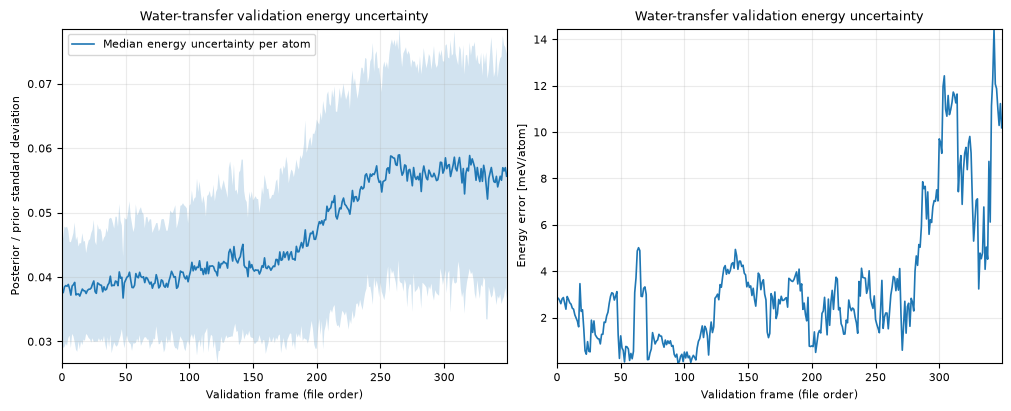

Saved: /home/pnovelli-iit.local/franken/results/water-transfer/run_261008_123847_7b8e9eed/analysis/validation_energy_gp_uncertainty.csv
Saved: /home/pnovelli-iit.local/franken/results/water-transfer/run_261008_123847_7b8e9eed/analysis/validation_energy_gp_uncertainty.png


In [13]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4), layout="constrained")
ci = uncertainties["iqr_atomic_energy_uncertainty"]
y = uncertainties["median_atomic_energy_uncertainty"]
ax = axs[0]
ax.plot(
    uncertainties["frame"], uncertainties["median_atomic_energy_uncertainty"],
    label="Median energy uncertainty per atom", color="tab:blue", linewidth=1.2,
)
ax.fill_between(uncertainties["frame"], (y-ci), (y+ci), alpha=0.2)
# ax.plot(
#     uncertainties["frame"], uncertainties["max_atomic_energy_uncertainty"],
#     label="Maximum per-atom energy uncertainty", color="tab:orange", linewidth=1.2,
# )
ax.set_title("Water-transfer validation energy uncertainty")
ax.set_xlabel("Validation frame (file order)")
ax.set_ylabel("Posterior / prior standard deviation")
ax.grid(alpha=0.25)
ax.legend()
ax.margins(0)

ax = axs[1]
ax.plot(
    uncertainties["frame"], uncertainties["absolute_energy_error_meV_per_atom"], color="tab:blue", linewidth=1.2,
)
ax.set_title("Water-transfer validation energy uncertainty")
ax.set_xlabel("Validation frame (file order)")
ax.set_ylabel("Energy error [meV/atom]")
ax.grid(alpha=0.25)
ax.margins(0)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = OUTPUT_DIR / "validation_energy_gp_uncertainty.csv"
plot_path = OUTPUT_DIR / "validation_energy_gp_uncertainty.png"
uncertainties.to_csv(csv_path, index=False)
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {csv_path}")
print(f"Saved: {plot_path}")

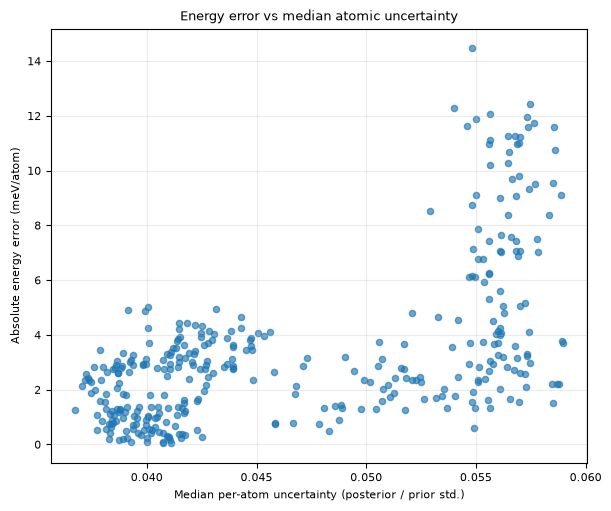

Saved: /home/pnovelli-iit.local/franken/results/water-transfer/run_261008_123847_7b8e9eed/analysis/validation_energy_error_vs_median_uncertainty.png


In [7]:
# Compare error magnitude with median per-atom uncertainty.
parity_fig, parity_ax = plt.subplots(figsize=(6, 5), layout="constrained")
parity_ax.scatter(
    uncertainties["median_atomic_energy_uncertainty"],
    uncertainties["absolute_energy_error_meV_per_atom"],
    s=20, alpha=0.65, color="tab:blue",
)
parity_ax.set_title("Energy error vs median atomic uncertainty")
parity_ax.set_xlabel("Median per-atom uncertainty (posterior / prior std.)")
parity_ax.set_ylabel("Absolute energy error (meV/atom)")
parity_ax.grid(alpha=0.25)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
parity_path = OUTPUT_DIR / "validation_energy_error_vs_median_uncertainty.png"
parity_fig.savefig(parity_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {parity_path}")